# Task 1 - Top Cuisines

#### Objective
Identify the top 3 most common cuisines in the dataset and calculate 
the percentage of restaurants serving each cuisine.

Step 1 → Load data and peek at Cuisines column

Step 2 → Split cuisines since one cell has multiple cuisines

Step 3 → Flatten all cuisines into one big list

Step 4 → Count each cuisine using Counter

Step 5 → Calculate percentage of top 3 cuisines

Step 6 → Visualize with bar chart

In [2]:
import pandas as pd
from collections import Counter

df = pd.read_excel('Restaurant Analysis.xlsx')
df.columns = df.columns.str.replace('ï»¿', '')

In [3]:
df['Cuisines'].head(10)

0            French, Japanese, Desserts
1                              Japanese
2      Seafood, Asian, Filipino, Indian
3                       Japanese, Sushi
4                      Japanese, Korean
5                               Chinese
6                       Asian, European
7    Seafood, Filipino, Asian, European
8               European, Asian, Indian
9                              Filipino
Name: Cuisines, dtype: object

#### Approach
Each restaurant can serve multiple cuisines listed in one cell, separated 
by commas. So we first split each entry, flatten all cuisines into one list, 
then count the frequency of each cuisine.

In [4]:
cuisine_split = df['Cuisines'].dropna().str.split(', ')
print(cuisine_split.head(5))

0          [French, Japanese, Desserts]
1                            [Japanese]
2    [Seafood, Asian, Filipino, Indian]
3                     [Japanese, Sushi]
4                    [Japanese, Korean]
Name: Cuisines, dtype: object


### Flattening the Cuisine List

After splitting, each restaurant has its own list of cuisines.
We need to combine all of them into one big list so we can count each cuisine.

In [5]:
all_cuisines = []
for cuisines in cuisine_split:
    for cuisine in cuisines:
        all_cuisines.append(cuisine)

print(all_cuisines[:10])
print("Total cuisines counted:", len(all_cuisines))

['French', 'Japanese', 'Desserts', 'Japanese', 'Seafood', 'Asian', 'Filipino', 'Indian', 'Japanese', 'Sushi']
Total cuisines counted: 19710


### Counting Each Cuisine

Now we count how many times each cuisine appears in our list
and pick the top 3 most common ones.

In [6]:
cuisine_counts = Counter(all_cuisines)
top3 = cuisine_counts.most_common(3)
print(top3)

[('North Indian', 3960), ('Chinese', 2735), ('Fast Food', 1986)]


#### Observation
The top 3 most common cuisins are 'North Indian', 'Chinese' and 'Fast food'. North Indian cuisine is appeared 3960 times. Chinese cuisine appeared 2735 times. Fast Food cuisine appeared 1986 times

### Calculating Percentage

To understand how dominant each cuisine is, we calculate what 
percentage of restaurants serve each of the top 3 cuisines.

In [7]:
total = len(df)
for cuisine, count in top3:
    percentage = (count / total) * 100
    print(cuisine, "-", round(percentage, 2), "%")

North Indian - 41.46 %
Chinese - 28.64 %
Fast Food - 20.79 %


#### Observation

- North Indian cuisine is served by 41.46% of restaurants, 
  making it the most dominant cuisine in the dataset.
- Chinese cuisine comes second at 28.64%.
- Fast Food is third at 20.79%.

Almost half of all restaurants serve North Indian food, which 
suggests the dataset is heavily focused on the Indian market.

### Visualizing Top 3 Cuisines

A bar chart is plotted to visually compare the number of 
restaurants serving each of the top 3 cuisines.

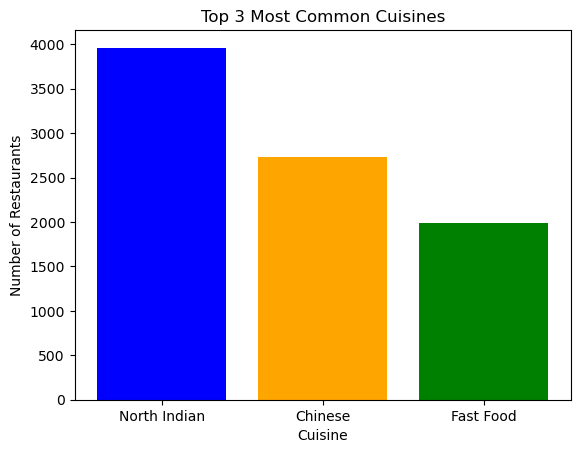

In [8]:
import matplotlib.pyplot as plt

#Extract cuisines names in top three
cuisines = [item[0] for item in top3]

#Extract counts from top three
counts = [item[1] for item in top3]

plt.bar(cuisines, counts, color=['blue', 'orange', 'green'])
plt.title('Top 3 Most Common Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.savefig('Task1_Top_Cuisines.png', dpi=150, bbox_inches='tight')
plt.show()

#### Observation

The bar chart clearly shows that North Indian cuisine dominates 
with nearly 4,000 restaurants, almost double that of Fast Food. 
Chinese cuisine sits in the middle. 